---

# CHAPTER 2: DATA CLEANING AND IMPUTATION

---

<br><br>

---

<span style='color:red'>
    
# Lesson 2: Converting and Analyzing Categorical Data

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Dataframe of the lesson
df = pd.read_csv('Resources/ds_salaries_clean.csv')
df.head()

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
0,2020,Data Scientist,Mid,FT,DE,L,0,76227.0
1,2020,Machine Learning Scientist,Senior,FT,JP,S,0,248257.0
2,2020,Big Data Engineer,Senior,FT,GB,M,50,104100.0
3,2020,Product Data Analyst,Mid,FT,HN,S,0,19097.0
4,2020,Machine Learning Engineer,Senior,FT,US,L,50,143225.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          607 non-null    int64  
 1   Designation           607 non-null    object 
 2   Experience            607 non-null    object 
 3   Employment_Status     607 non-null    object 
 4   Employee_Location     607 non-null    object 
 5   Company_Size          607 non-null    object 
 6   Remote_Working_Ratio  607 non-null    int64  
 7   Salary_USD            607 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 38.1+ KB


---

## Previewing the Data

In [4]:
# We can use the select_dtypes method to filter any non-numeric data.
df.select_dtypes('object').head()

,Designation,Experience,Employment_Status,Employee_Location,Company_Size
0,Data Scientist,Mid,FT,DE,L
1,Machine Learning Scientist,Senior,FT,JP,S
2,Big Data Engineer,Senior,FT,GB,M
3,Product Data Analyst,Mid,FT,HN,S
4,Machine Learning Engineer,Senior,FT,US,L


<br><br>

---

## Job Titles

In [5]:
# Let's examine frequency of values in the Designation column.
df.Designation.value_counts()

Designation
Data Scientist                              143
Data Engineer                               132
Data Analyst                                 97
Machine Learning Engineer                    41
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Machine Learning Scientist                    8
Big Data Engineer                             8
Director of Data Science                      7
AI Scientist                                  7
Principal Data Scientist                      7
Data Science Consultant                       7
Data Analytics Manager                        7
BI Data Analyst                               6
Computer Vision Engineer                      6
ML Engineer                                   6
Lead Data Engineer                            6
Applied Data Scientist                        5
Business Data Analyst                         5
Data Engineering Manager    

In [6]:
# We can count how many unique job titles there are using pandas dot-nunique method.
df.Designation.nunique()

50

<br><br>

---

### Seaborn Plot - Fast Plot

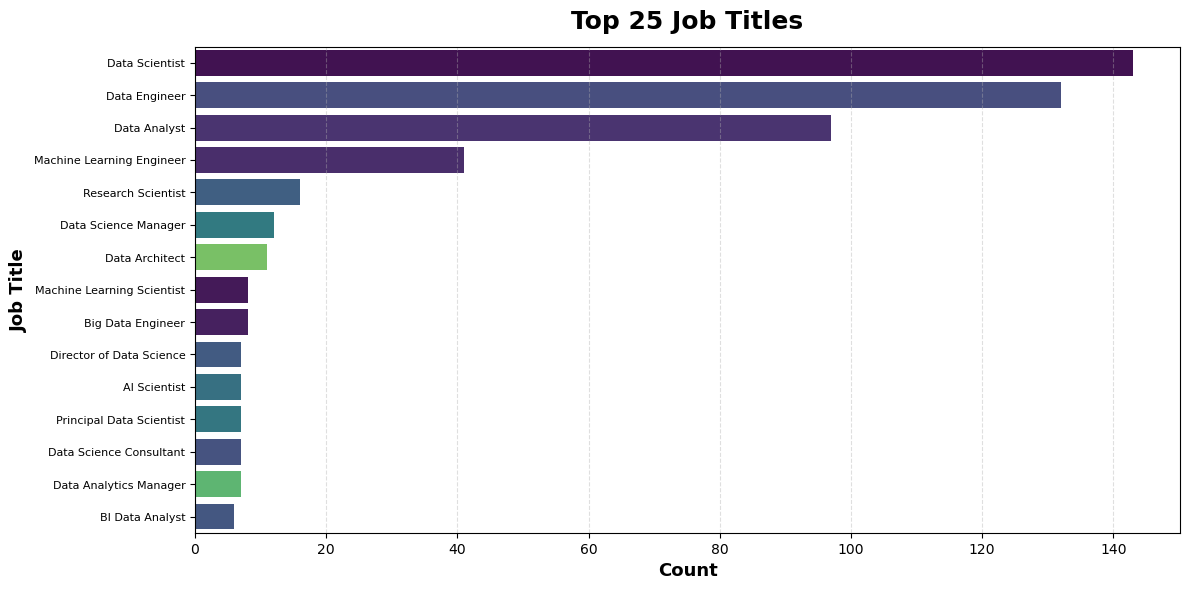

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Designation',
              order=df.Designation.value_counts().index[:15],
              hue='Designation', palette='viridis')
# ---------------------------------------------------------------------
plt.title('Top 25 Job Titles', fontsize=18, fontweight='bold', y=1.02)
plt.xlabel('Count', fontsize=13, fontweight='bold')
plt.ylabel('Job Title', fontsize=13, fontweight='bold')
plt.yticks(fontsize=8)
# ---------------------------------------------------------------------
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<br><br>

---

### Seaborn & Matplotlib API Object Oriented - Pro Plot

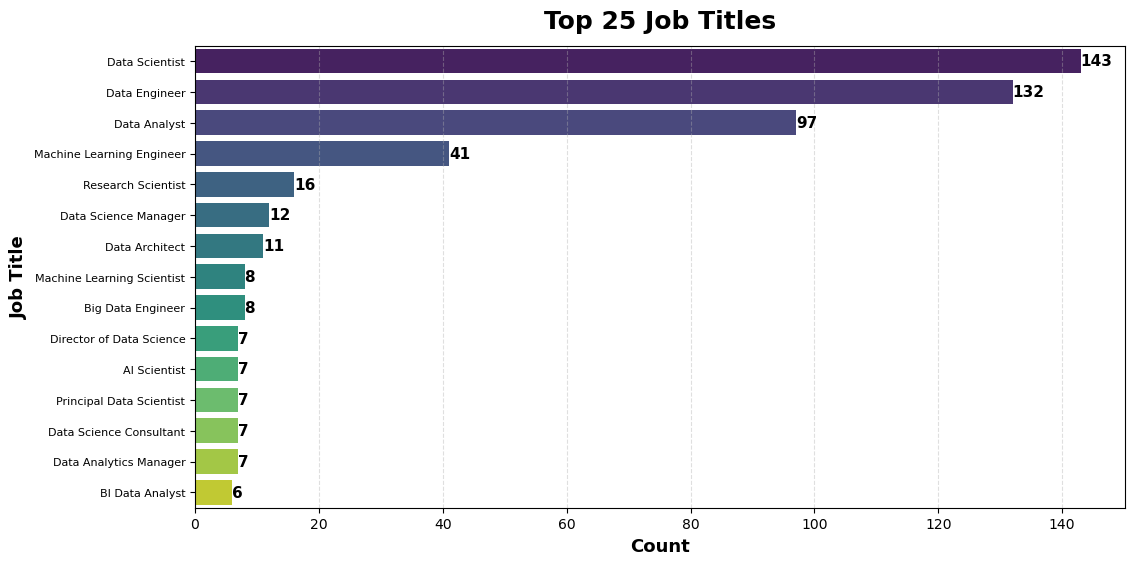

In [8]:
top_15 = df.Designation.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))

# Because of the Series (top_10) we don't set 'data='
sns.barplot(y=top_15.index, x=top_15.values, 
            hue=top_15.index, palette='viridis', 
            legend=False, ax=ax)

for i, value in enumerate (top_15.values):
    ax.text(x=value, y=i, s=str(value),
        ha='left', va='center',
            fontsize=11, fontweight='bold')

# ---------------------------------------------------------------------
plt.title('Top 25 Job Titles', fontsize=18, fontweight='bold', y=1.02)
plt.xlabel('Count', fontsize=13, fontweight='bold')
plt.ylabel('Job Title', fontsize=13, fontweight='bold')
plt.yticks(fontsize=8)
# ---------------------------------------------------------------------
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

<br><br>

---
---
---

<span style='color:red'>
    
## Strategies for Addressing Missing Data


The current format of the data limits our ability to generate insights. 

We can use the pandas `series.str.contains` method, which allows us to search a column for a specific string or multiple strings. 

Say we want to know which "job titles" have `Scientist` in them. We use the `str.contains` method on the `Designation` column, passing the word `Scientist`. This returns True or False values depending on whether the row contains this word.

<br><br>

---

### 1. Finding Multiple Phrases in Strings

---

Now we have a sense of how this method works, let's define a list of job titles we want to find. 

<span style='color:orange'>
    
**We start by creating a list with the different categories of data roles**, which `will become the values of a new column in our DataFrame`.

In [9]:
job_categories = ['Data Science', 'Data Analytics', 
                  'Data Engineering', 'Machine Learning', 
                  'Managerial', 'Consultant']
job_categories # This is the ChoiceList for np.select()

['Data Science',
 'Data Analytics',
 'Data Engineering',
 'Machine Learning',
 'Managerial',
 'Consultant']

<br><br>

---

We then need to create `variables containing our filters`. 

<span style='color:orange'>
    
We will look for **Data Scientist** or **NLP** for `data science roles`. 
We'll use **Analyst** or **Analytics** for `data analyst roles`. We repeat this for `data engineer`, `machine learning engineer`, `managerial`, and `consultant` roles.

In [10]:
data_science = "Data Scientist|NLP"
data_analyst = "Analyst|Analytics"
data_engineer = "Data Engineer|ETL|Architect|Infrastructure"
ml_engineer = "Machine Learning|ML|Big Data|AI"
manager = "Manager|Head|Director|Lead|Principal|Staff"
consultant = "Consultant|Freelance"

<br><br>

---

<span style='color:orange'>
    
The next step is to **create a list with our range of conditions for the `str.contains` method**. We add data science, data analyst, data engineer, and all remaining roles, remembering to close our list.

In [11]:
conditions = [
    (df['Designation'].str.contains(data_science)),
    (df['Designation'].str.contains(data_analyst)),
    (df['Designation'].str.contains(data_engineer)),
    (df['Designation'].str.contains(ml_engineer)),
    (df['Designation'].str.contains(manager)),
    (df['Designation'].str.contains(consultant))
]

<br><br>

---

### 2. Creating the Categorical Columns

<br>

Finally, we can create our new `Job_Category` column by using NumPy's .select function.

- It takes a list of conditions as the first argument.
- Followed by a list of arrays to search for the conditions in.
- Then we select `default='Other'` for all the conditions that were not listed

In [12]:
df['Job_Category'] = np.select(conditions, # list of conditions
                               job_categories, # list of arrays
                               default = 'Other' # value for conditions not listed in "conditions"
                              )

df[['Designation', 'Job_Category']].head()

,Designation,Job_Category
0,Data Scientist,Data Science
1,Machine Learning Scientist,Machine Learning
2,Big Data Engineer,Data Engineering
3,Product Data Analyst,Data Analytics
4,Machine Learning Engineer,Machine Learning


<br><br>

---

### 3. Visualizing Job Categories Frequency

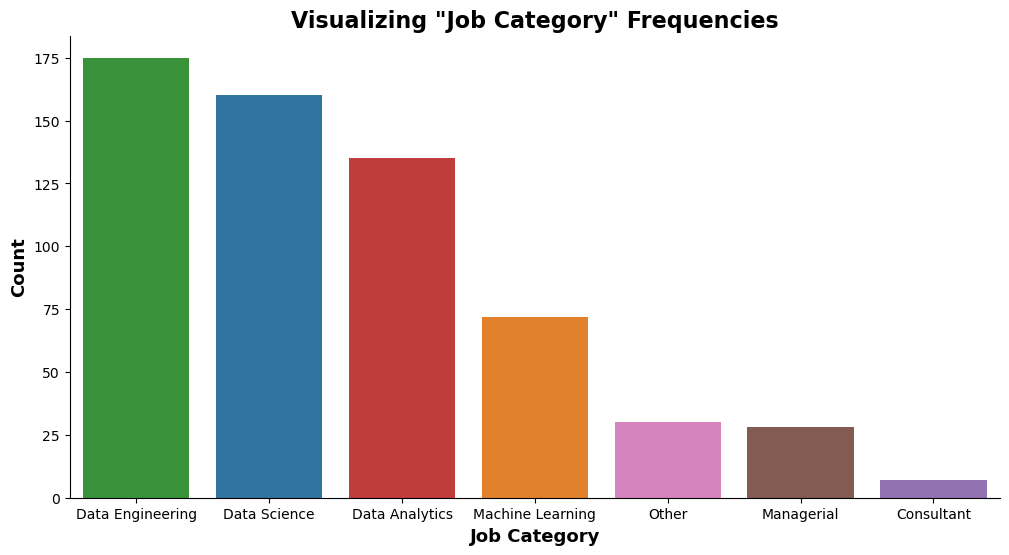

In [13]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Job_Category', hue='Job_Category',
              order=['Data Engineering', 'Data Science', 'Data Analytics',
                     'Machine Learning', 'Other', 'Managerial', 'Consultant'])
# --------------------------------------------------
plt.title('Visualizing "Job Category" Frequencies', fontsize=16, fontweight='bold')
plt.xlabel('Job Category', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
# --------------------------------------------------
sns.despine()
plt.show()

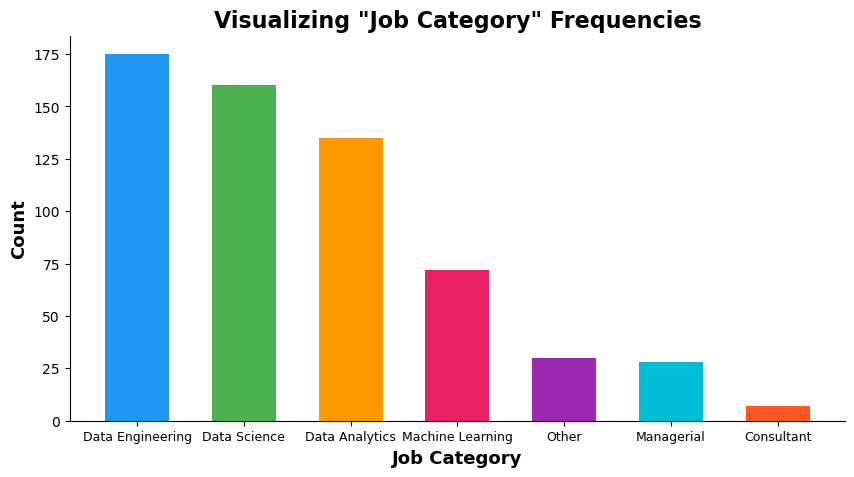

In [14]:
res = df.Job_Category.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(res.index, res, width=0.6,
       color=["#2196F3", "#4CAF50", "#FF9800", "#E91E63",
              "#9C27B0", "#00BCD4", "#FF5722"])
# --------------------------------------------------
ax.set_title('Visualizing "Job Category" Frequencies', fontsize=16, fontweight='bold')
ax.set_xlabel('Job Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=9)
# --------------------------------------------------
sns.despine()
plt.show()

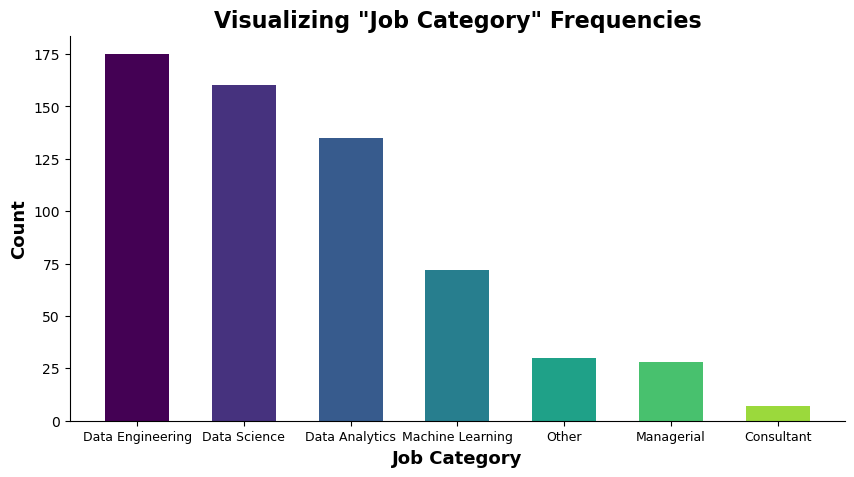

In [15]:
res = df.Job_Category.value_counts()

cmap = plt.cm.viridis                       # colormap
colors = cmap(np.linspace(0, 0.85, len(res)))  # N equidistant colors

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(res.index, res.values, width=0.6, color=colors)
# --------------------------------------------------
ax.set_title('Visualizing "Job Category" Frequencies', fontsize=16, fontweight='bold')
ax.set_xlabel('Job Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=9)
# --------------------------------------------------
sns.despine()
plt.show()